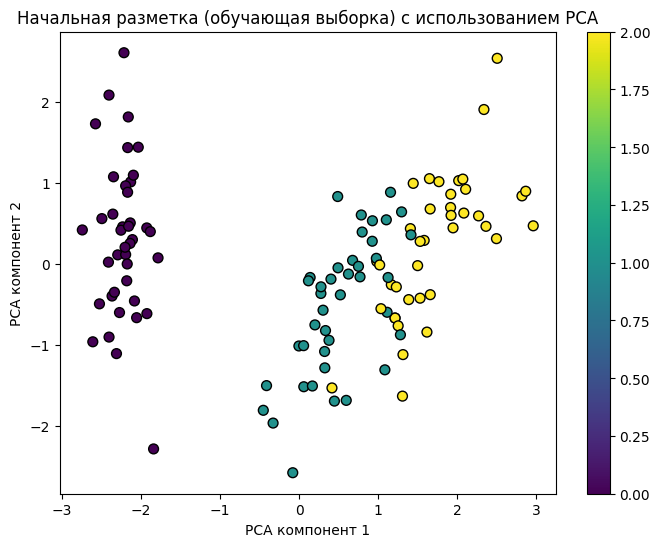

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris = datasets.load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', edgecolor='k', s=50)
plt.title("Начальная разметка (обучающая выборка) с использованием PCA")
plt.xlabel('PCA компонент 1')
plt.ylabel('PCA компонент 2')
plt.colorbar()
plt.show()


Accuracy: 0.97
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



<Figure size 600x500 with 0 Axes>

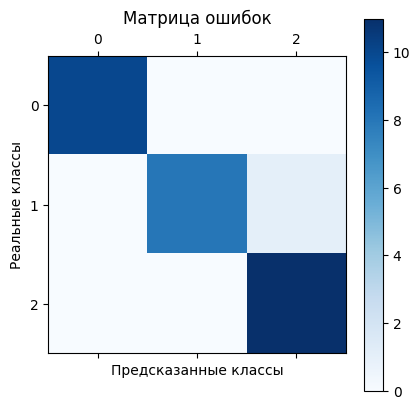

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

model = SVC(kernel='linear', random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
class_names = iris.target_names

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
plt.matshow(conf_matrix, cmap='Blues')
plt.title("Матрица ошибок")
plt.colorbar()
plt.ylabel('Реальные классы')
plt.xlabel('Предсказанные классы')
plt.show()


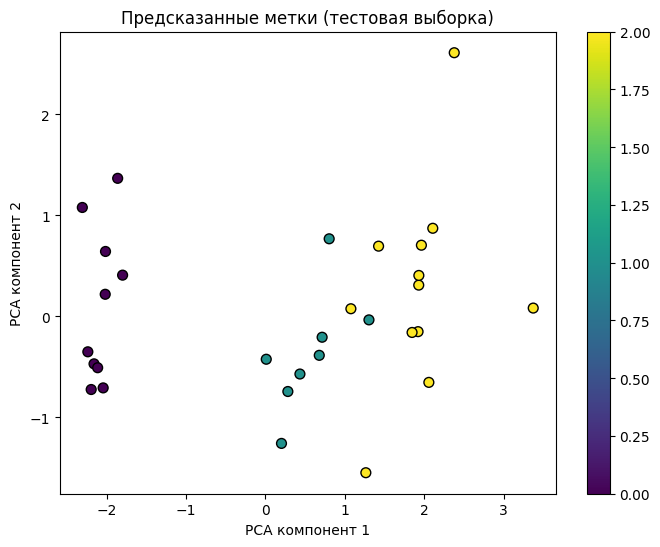

In [ ]:
y_pred_pca = pca.transform(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_pca[:, 0], y_pred_pca[:, 1], c=y_pred, cmap='viridis', edgecolor='k', s=50)
plt.title("Предсказанные метки (тестовая выборка)")
plt.xlabel('PCA компонент 1')
plt.ylabel('PCA компонент 2')
plt.colorbar()
plt.show()


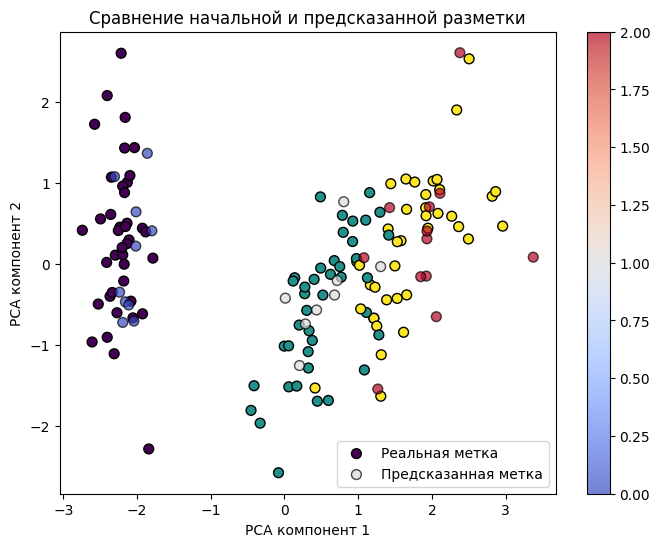

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', label='Реальная метка', edgecolor='k', s=50)

plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred, cmap='coolwarm', label='Предсказанная метка', edgecolor='k', s=50, alpha=0.7)

plt.title("Сравнение начальной и предсказанной разметки")
plt.xlabel('PCA компонент 1')
plt.ylabel('PCA компонент 2')
plt.colorbar()
plt.legend()
plt.show()
